In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
df =pd.read_csv(r"C:\Users\Divyani Singh\OneDrive\Desktop\Internshala DS Course\All_Courses\ML\Snapdeal_Project\Snapdeal_Cleaned.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 24 columns):
 #   Column                                         Non-Null Count  Dtype
---  ------                                         --------------  -----
 0   Timestamp                                      800 non-null    str  
 1   age                                            800 non-null    int64
 2   Gender                                         800 non-null    str  
 3   Purchase_Frequency                             800 non-null    str  
 4   Purchase_Categories                            800 non-null    str  
 5   Personalized_Recommendation_Frequency          800 non-null    str  
 6   Browsing_Frequency                             800 non-null    str  
 7   Product_Search_Method                          800 non-null    str  
 8   Search_Result_Exploration                      800 non-null    str  
 9   Customer_Reviews_Importance                    800 non-null    int64
 10  Add_to_Cart_B

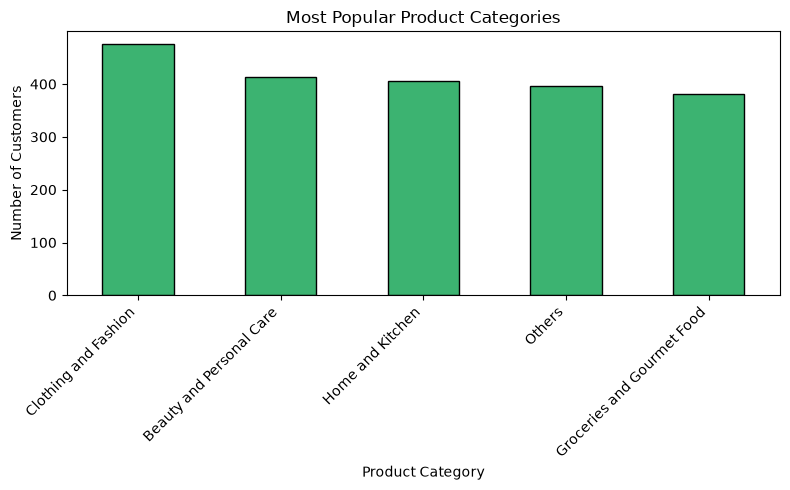

In [ ]:
"""Creating Visualization for Purchase Category"""
plt.figure(figsize=(8,5))
all_categories= df['Purchase_Categories'].str.split(';').explode()
all_categories.value_counts().plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Most Popular Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




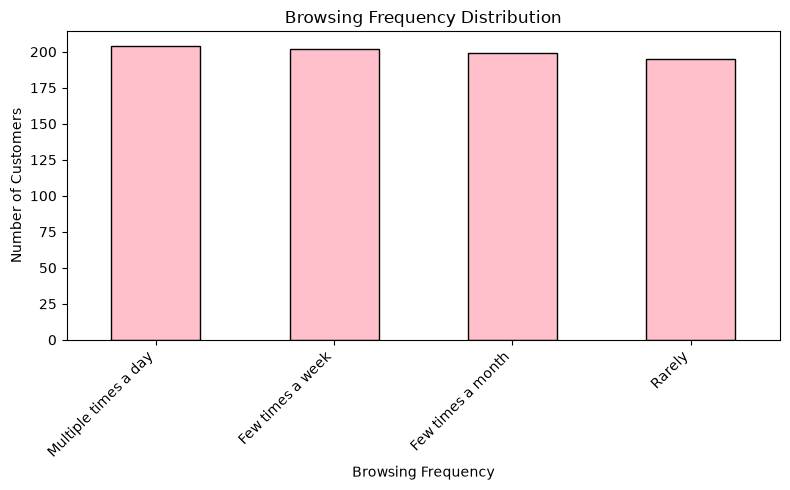

In [14]:
""" Creating Visualization for Browsing Frequency Distribution"""

plt.figure(figsize=(8,5))
df['Browsing_Frequency'].value_counts().plot(kind='bar', color='pink', edgecolor='black')
plt.title('Browsing Frequency Distribution')
plt.xlabel('Browsing Frequency')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

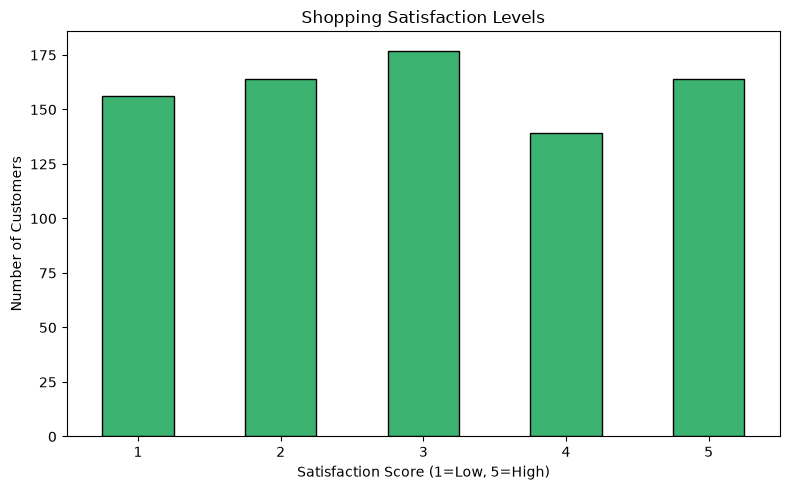

In [15]:
"""Creating Visualization for Satisfaction Levels"""
plt.figure(figsize=(8,5))
df['Shopping_Satisfaction'].value_counts().sort_index().plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Shopping Satisfaction Levels')
plt.xlabel('Satisfaction Score (1=Low, 5=High)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Column created:
   Recommendation_Helpfulness  Recommendation_Helpfulness_Score
0                        Yes                                 3
1                         No                                 1
2                  Sometimes                                 2
3                  Sometimes                                 2
4                        Yes                                 3


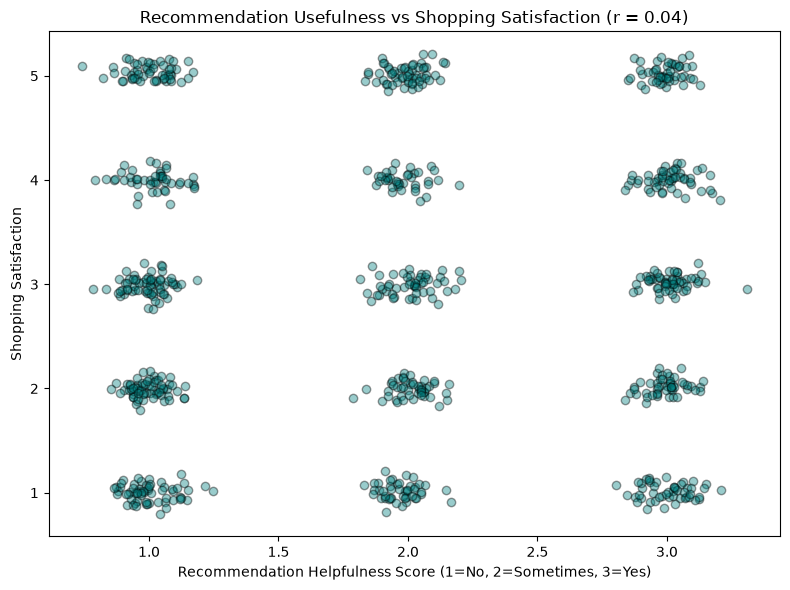

In [20]:
"""Visualizing Correlation between recommendation usefulness and satisfaction"""
helpfulness_order = {
    'No': 1,
    'Sometimes': 2,
    'Yes': 3
}

df['Recommendation_Helpfulness_Score'] = df['Recommendation_Helpfulness'].map(helpfulness_order)

print("Column created:\n", df[['Recommendation_Helpfulness', 'Recommendation_Helpfulness_Score']].head())
np.random.seed(42)
jitter_x = df['Recommendation_Helpfulness_Score'] + np.random.normal(0, 0.08, size=len(df))
jitter_y = df['Shopping_Satisfaction'] + np.random.normal(0, 0.08, size=len(df))

correlation = df['Recommendation_Helpfulness_Score'].corr(df['Shopping_Satisfaction'])

plt.figure(figsize=(8,6))
plt.scatter(jitter_x, jitter_y, alpha=0.4, edgecolor='black', color='teal')
plt.title(f'Recommendation Usefulness vs Shopping Satisfaction (r = {round(correlation,3)})')
plt.xlabel('Recommendation Helpfulness Score (1=No, 2=Sometimes, 3=Yes)')
plt.ylabel('Shopping Satisfaction')
plt.tight_layout()
plt.show()
